In [2]:
!git clone https://github.com/quark28/miniml.git
%cd miniml

Cloning into 'miniml'...
remote: Enumerating objects: 207, done.
remote: Counting objects: 100% (207/207), done.
remote: Compressing objects: 100% (155/155), done.
remote: Total 207 (delta 99), reused 155 (delta 47), pack-reused 0 (from 0)
Receiving objects: 100% (207/207), 1.46 MiB | 11.64 MiB/s, done.
Resolving deltas: 100% (99/99), done.
/content/miniml


In [3]:
from miniml.tools.pca import PCA

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA as SklearnPCA

In [5]:
# Генерация данных
np.random.seed(42)
X = np.dot(np.random.rand(100, 2), np.random.rand(2, 2))

# Обучение
my_pca = PCA()
my_pca.fit(X)

sk_pca = SklearnPCA(n_components=2)
sk_pca.fit(X)

# Assertions
print("Проверка Mean:", np.allclose(my_pca.mean_, sk_pca.mean_))
# Проверка векторов (с точностью до знака)
for i in range(2):
    cos_sim = np.abs(np.dot(my_pca.components_[:, i], sk_pca.components_[i, :]))
    assert np.isclose(cos_sim, 1.0), f"Компонента {i} не совпадает с sklearn"

print("Все тесты пройдены успешно!")

Проверка Mean: True
Все тесты пройдены успешно!


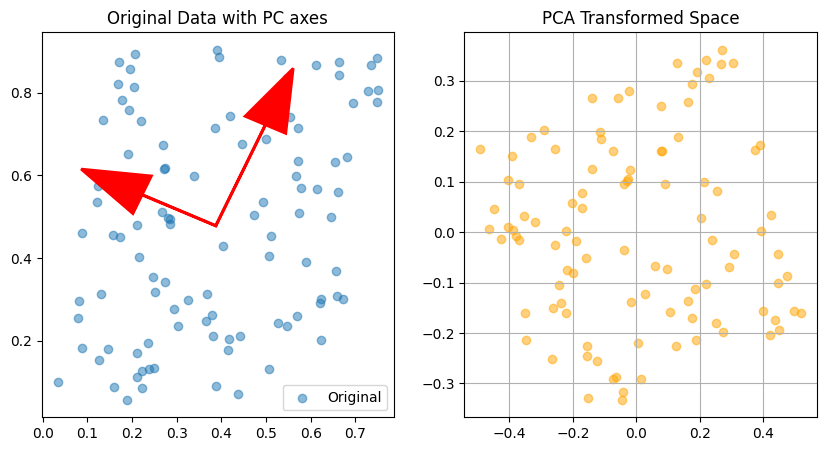

In [7]:

X_transformed = my_pca.transform(X, k=2)

plt.figure(figsize=(10, 5))

# Оригинал
plt.subplot(1, 2, 1)
plt.scatter(X[:,0], X[:,1], alpha=0.5, label='Original')
# Рисуем главные компоненты
for i in range(2):
    vec = my_pca.components_[:, i] * np.sqrt(my_pca.eigenvalues_[i])
    plt.arrow(my_pca.mean_[0,0], my_pca.mean_[0,1], vec[0], vec[1],
              head_width=0.1, color='red', linewidth=2)
plt.title("Original Data with PC axes")
plt.legend()

plt.subplot(1, 2, 2)
plt.scatter(X_transformed[:,0], X_transformed[:,1], alpha=0.5, color='orange')
plt.title("PCA Transformed Space")
plt.grid(True)
plt.show()